In [1]:
import numpy as np
import equiboots as eqb

## Testing Exception for NaN values in `y_true`

In [2]:
data_nan = {
    "asian": {"y_true": np.array([1, 0, np.nan]), "y_prob": np.array([0.9, 0.2, 0.8])},
    "black": {"y_true": np.array([0, 1, 0]), "y_prob": np.array([0.1, 0.8, 0.3])},
}

try:
    eqb.eq_plot_group_curves(
        data_nan,
        curve_type="roc",
        title="ROC Curves by Group",
    )
except ValueError as e:
    print(e)

NaN values found in y_true for group 'asian'


## Testing Exception for Missing `y_true`

In [3]:
data_missing_y_true = {
    "asian": {"y_prob": np.array([0.9, 0.2, 0.8])},  # Missing y_true
    "black": {"y_true": np.array([0, 1, 0]), "y_prob": np.array([0.1, 0.8, 0.3])},
}

try:
    eqb.eq_plot_group_curves(
        data_missing_y_true,
        curve_type="roc",
        title="ROC Curves by Group",
    )
except ValueError as e:
    print(e)

y_true missing for group 'asian'


##  Testing Invalid Group Name in `curve_kwgs`

In [4]:
data_kwgs = {
    "asian": {"y_true": np.array([1, 0, 1]), "y_prob": np.array([0.9, 0.2, 0.8])},
    "black": {"y_true": np.array([0, 1, 0]), "y_prob": np.array([0.1, 0.8, 0.3])},
}

curve_kwgs = {
    "asian": {"linestyle": "--"},
    "invalid_group": {"color": "red"},  # Invalid group name
}

try:
    eqb.eq_plot_group_curves(
        data_kwgs,
        curve_type="roc",
        curve_kwgs=curve_kwgs,
        title="ROC Curves by Group",
    )
except ValueError as e:
    print(e)

curve_kwgs contains invalid group names: {'invalid_group'}


## Invalid `line_kwgs` in `eq_plot_group_curves`

In [5]:
data_group_curves = {
    "asian": {"y_true": np.array([1, 0, 1]), "y_prob": np.array([0.9, 0.2, 0.8])},
    "black": {"y_true": np.array([0, 1, 0]), "y_prob": np.array([0.1, 0.8, 0.3])},
}

line_kwgs = {"invalid_arg": "value"}  # Invalid argument

try:
    eqb.eq_plot_group_curves(
        data_group_curves,
        curve_type="roc",
        line_kwgs=line_kwgs,
        title="ROC Curves by Group",
    )
except ValueError as e:
    print(e)

line_kwgs contains invalid plot arguments: {'invalid_arg'}. Valid arguments are: {'marker', 'markerfacecolor', 'markeredgecolor', 'color', 'dash_joinstyle', 'solid_joinstyle', 'alpha', 'linestyle', 'zorder', 'solid_capstyle', 'linewidth', 'dash_capstyle', 'markeredgewidth', 'markersize'}


In [6]:
boot_sliced_data = [
    {
        "asian": {"y_true": np.array([1, 0, 1]), "y_prob": np.array([0.9, 0.2, 0.8])},
        "black": {"y_true": np.array([0, 1, 0]), "y_prob": np.array([0.1, 0.8, 0.3])},
    },
]

line_kwgs = {"invalid_arg": "value"}  # Invalid argument

try:
    eqb.eq_plot_bootstrapped_group_curves(
        boot_sliced_data,
        curve_type="roc",
        line_kwgs=line_kwgs,
        title="Bootstrapped ROC Curves by Group",
    )
except ValueError as e:
    print(e)

line_kwgs contains invalid plot arguments: {'invalid_arg'}. Valid arguments are: {'marker', 'markerfacecolor', 'markeredgecolor', 'color', 'dash_joinstyle', 'solid_joinstyle', 'alpha', 'linestyle', 'zorder', 'solid_capstyle', 'linewidth', 'dash_capstyle', 'markeredgewidth', 'markersize'}


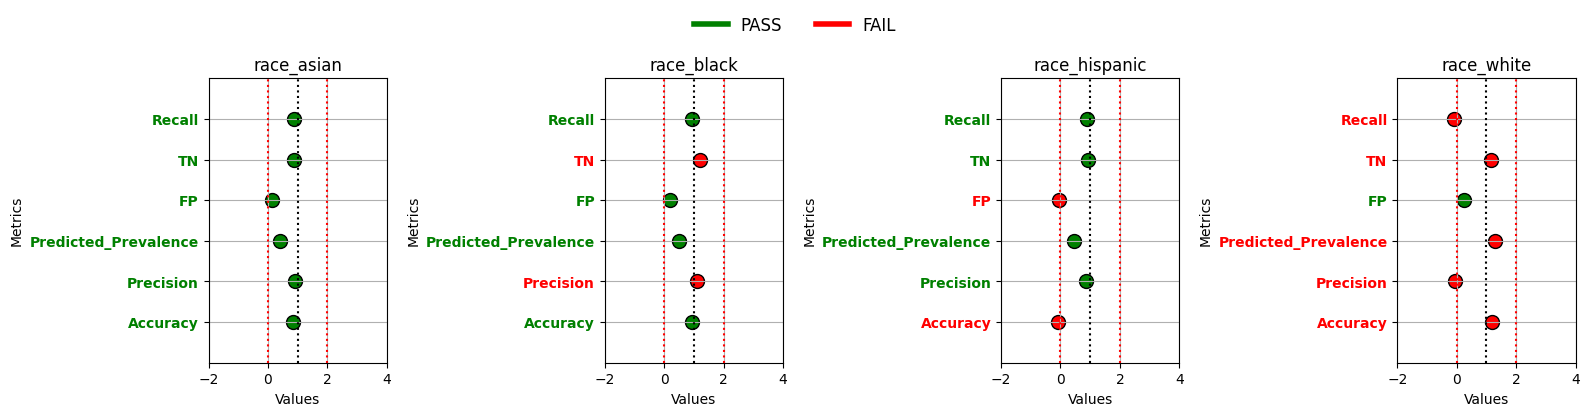

In [7]:
# Synthetic point estimate data for classic metrics (non-bootstrapped)
metrics_data = [
    {
        "asian": {
            "Accuracy": 0.85,  # PASS
            "Precision": 0.90,  # PASS
            "Predicted_Prevalence": 0.40,  # PASS
            "FP": 0.15,  # PASS
            "TN": 0.88,  # PASS
            "Recall": 0.87,  # PASS
        },
        "black": {
            "Accuracy": 0.95,  # PASS
            "Precision": 1.1,  # FAIL (above 1)
            "Predicted_Prevalence": 0.50,  # PASS
            "FP": 0.20,  # PASS
            "TN": 1.2,  # FAIL (above 1)
            "Recall": 0.92,  # PASS
        },
        "hispanic": {
            "Accuracy": -0.1,  # FAIL (below 0)
            "Precision": 0.87,  # PASS
            "Predicted_Prevalence": 0.45,  # PASS
            "FP": -0.05,  # FAIL (below 0)
            "TN": 0.91,  # PASS
            "Recall": 0.89,  # PASS
        },
        "white": {
            "Accuracy": 1.2,  # FAIL (above 1)
            "Precision": -0.05,  # FAIL (below 0)
            "Predicted_Prevalence": 1.3,  # FAIL (above 1)
            "FP": 0.25,  # PASS
            "TN": 1.15,  # FAIL (above 1)
            "Recall": -0.10,  # FAIL (below 0)
        },
    }
]

# Plot with pass/fail indicators
eqb.eq_disparity_metrics_violin_pass_fail_plot(
    metrics_data=metrics_data,
    metric_cols=[
        "Accuracy",
        "Precision",
        "Predicted_Prevalence",
        "FP",
        "TN",
        "Recall",
    ],
    name="race",
    categories=["asian", "black", "hispanic", "white"],
    pass_range=(0.0, 1.0),  # Pass if the point estimate is within [0, 1]
    include_legend=True,
)

In [8]:
import numpy as np

# Generate synthetic distribution data for classic metrics
np.random.seed(42)  # For reproducibility
metrics_data = []

# Simulate 10 data points per group per metric
for _ in range(10):
    entry = {
        "asian": {
            "Accuracy": np.random.uniform(0.8, 0.9),  # Within [0, 1] (PASS)
            "Precision": np.random.uniform(0.85, 0.95),  # Within [0, 1] (PASS)
            "Predicted_Prevalence": np.random.uniform(
                0.35, 0.45
            ),  # Within [0, 1] (PASS)
            "FP": np.random.uniform(0.1, 0.2),  # Within [0, 1] (PASS)
            "TN": np.random.uniform(0.85, 0.95),  # Within [0, 1] (PASS)
            "Recall": np.random.uniform(0.8, 0.9),  # Within [0, 1] (PASS)
        },
        "black": {
            "Accuracy": np.random.uniform(0.9, 1.0),  # Within [0, 1] (PASS)
            "Precision": np.random.uniform(1.0, 1.2),  # Extends above 1 (FAIL)
            "Predicted_Prevalence": np.random.uniform(
                0.45, 0.55
            ),  # Within [0, 1] (PASS)
            "FP": np.random.uniform(0.15, 0.25),  # Within [0, 1] (PASS)
            "TN": np.random.uniform(1.1, 1.3),  # Extends above 1 (FAIL)
            "Recall": np.random.uniform(0.9, 1.0),  # Within [0, 1] (PASS)
        },
        "hispanic": {
            "Accuracy": np.random.uniform(-0.2, 0.0),  # Extends below 0 (FAIL)
            "Precision": np.random.uniform(0.8, 0.9),  # Within [0, 1] (PASS)
            "Predicted_Prevalence": np.random.uniform(0.4, 0.5),  # Within [0, 1] (PASS)
            "FP": np.random.uniform(-0.1, 0.0),  # Extends below 0 (FAIL)
            "TN": np.random.uniform(0.85, 0.95),  # Within [0, 1] (PASS)
            "Recall": np.random.uniform(0.85, 0.95),  # Within [0, 1] (PASS)
        },
        "white": {
            "Accuracy": np.random.uniform(1.1, 1.3),  # Extends above 1 (FAIL)
            "Precision": np.random.uniform(-0.1, 0.0),  # Extends below 0 (FAIL)
            "Predicted_Prevalence": np.random.uniform(
                1.2, 1.4
            ),  # Extends above 1 (FAIL)
            "FP": np.random.uniform(0.2, 0.3),  # Within [0, 1] (PASS)
            "TN": np.random.uniform(1.1, 1.2),  # Extends above 1 (FAIL)
            "Recall": np.random.uniform(-0.2, -0.1),  # Extends below 0 (FAIL)
        },
    }
    metrics_data.append(entry)

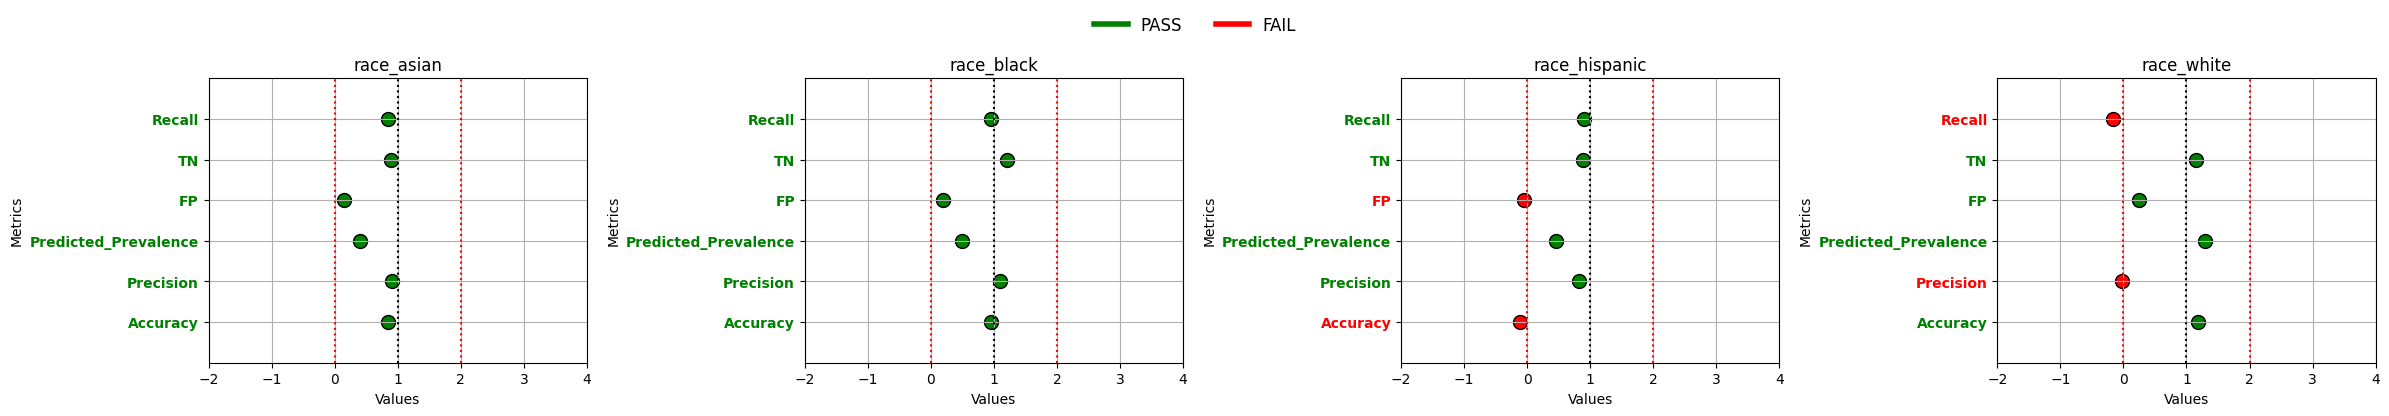

In [12]:
eqb.eq_disparity_metrics_violin_pass_fail_plot(
    metrics_data=metrics_data,
    force_point_estimate=True,
    metric_cols=[
        "Accuracy",
        "Precision",
        "Predicted_Prevalence",
        "FP",
        "TN",
        "Recall",
    ],
    name="race",
    categories=["asian", "black", "hispanic", "white"],
    pass_range=(0.0, 2.0),  # Pass if the point estimate is within [0, 1]
    include_legend=True,
    figsize=(24, 4),
)